In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
url = "https://drive.google.com/uc?id=1iKy23bMtEQShF_weneRNnYrFmzvpPOI3"
df = pd.read_csv(url)

In [4]:
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


In [5]:
#What is the range of selling prices in the dataset
max_price = df.selling_price.max()
min_price = df.selling_price.min()
p_range = max_price - min_price
print(f"The price spans a {p_range}-unit interval, From {min_price} to {max_price}")

The price spans a 755000-unit interval, From 5000 to 760000


In [6]:
#What is the median selling price for bikes in the dataset
midn = df.selling_price.median()
midn

np.float64(45000.0)

In [7]:
#What is the most common seller type
df.seller_type.value_counts().head(1)

seller_type
Individual    1055
Name: count, dtype: int64

In [8]:
#How many bikes have driven more than 50,000 kilometers
len(df[df['km_driven']>50000])

170

In [9]:
#What is the average km_driven value for each ownership type

df.groupby('owner')['km_driven'].mean()

owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64

In [10]:
df.dtypes

name                  object
selling_price          int64
year                   int64
seller_type           object
owner                 object
km_driven              int64
ex_showroom_price    float64
dtype: object

In [11]:
df.shape

(1061, 7)

In [12]:
#What proportion of bikes are from the year 2015 or older
old_bikes  = (df.year<=2015).sum()
total_bikes = df.shape[0]
#proportion
proportion = old_bikes/total_bikes
print(f"Proportion of bikes from 2015 or older: {proportion:.2%}")


Proportion of bikes from 2015 or older: 56.64%


In [13]:
#What is the trend of missing values across the dataset
missing_counts = df.isnull().sum()
null_percentage = missing_counts/len(df)

In [14]:
ms_df = pd.DataFrame({'missing_counts':missing_counts,'null_percentage':null_percentage}).sort_values(by='missing_counts',ascending=False)
ms_df

,missing_counts,null_percentage
ex_showroom_price,435,0.409991
selling_price,0,0.000000
name,0,0.000000
year,0,0.000000
seller_type,0,0.000000
owner,0,0.000000
km_driven,0,0.000000


In [15]:
#What is the highest ex_showroom_price recorded, and for which bike
max_price = df.ex_showroom_price.max()
bike_name = df.loc[df.ex_showroom_price.idxmax(),'name']

print(f"Highest ex_showroom_price: ₹{max_price:,.0f}")
print(f"Bike with highest price: {bike_name}")


Highest ex_showroom_price: ₹1,278,000
Bike with highest price: Harley-Davidson Street Bob


In [16]:
#What is the total number of bikes listed by each seller type
df['seller_type'].value_counts()

seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64

In [17]:
#What is the relationship between selling_price and km_driven for first-owner bikes
(df[['selling_price','km_driven']][df['owner']=='1st owner']).corr()

,selling_price,km_driven
selling_price,1.000000,-0.243482
km_driven,-0.243482,1.000000


In [18]:
#Identify and remove outliers in the km_driven column using the IQR method
q1 = np.percentile(df.km_driven,25)
q3 = np.percentile(df.km_driven,75)
iqr = q3-q1


lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_no_outliers = df[(df.km_driven>=lower_bound)&(df.km_driven<=upper_bound)]

removed_count = len(df) - len(df_no_outliers)
print(f"Removed {removed_count} outliers from km_driven column.")


df_no_outliers

Removed 39 outliers from km_driven column.


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1054,Hero CBZ Xtreme,20000,2010,Individual,1st owner,50000,78700.0
1055,Bajaj ct 100,18000,2017,Individual,1st owner,35000,32000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0


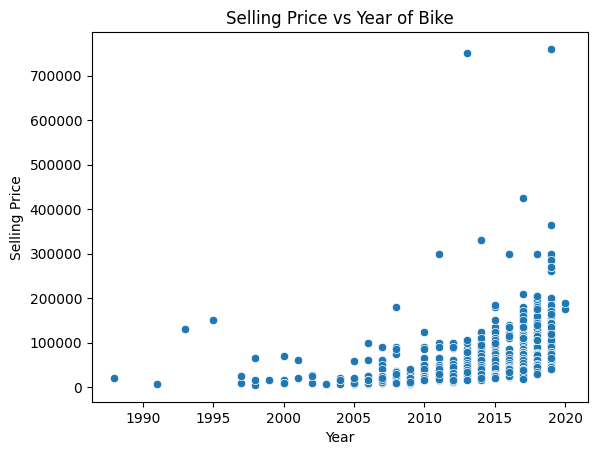

In [19]:
#Perform a bivariate analysis to visualize the relationship between year 
#and selling_price
sns.scatterplot(x='year',y='selling_price',data=df)
plt.title('Selling Price vs Year of Bike')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

In [20]:
#What is the average depreciation in selling price based on the 
#bike's age (current year - manufacturing year)?


In [34]:
df['ex_showroom_price'] = df['ex_showroom_price'].fillna(df.groupby('name')['ex_showroom_price'].transform('median'))

In [36]:
df['ex_showroom_price'] = df['ex_showroom_price'].fillna(df['ex_showroom_price'].median())

In [50]:
current_year = 2025
df['age'] = current_year - df['year']
df['depreciation_per_year'] = df.selling_price/df.age

dep_by_age = df.groupby('age',as_index=False)['depreciation_per_year'].mean().sort_values('age')

In [51]:
dep_by_age

,age,depreciation_per_year
0,5,36666.666667
1,6,19948.251938
2,7,12522.910578
3,8,9861.842105
4,9,6496.557632
5,10,5650.000000
6,11,4424.375624
7,12,4261.415525
8,13,2749.876923
9,14,2546.837237


In [54]:
#Which bike names are priced significantly above the average price for their 
#manufacturing year
year_stats = df.groupby('year',as_index=False)['selling_price'].agg(['mean','std']).reset_index()
year_stats

,index,year,mean,std
0,0,1988,20000.000000,NaN
1,1,1991,6000.000000,NaN
2,2,1993,130000.000000,NaN
3,3,1995,150000.000000,NaN
4,4,1997,17500.000000,10606.601718
5,5,1998,28333.333333,32145.502537
6,6,1999,15000.000000,NaN
7,7,2000,20833.333333,24169.540059
8,8,2001,40000.000000,28284.271247
9,9,2002,20666.666667,10115.993937


In [60]:
year_stats.rename(columns={'mean':'year_avg','std':'year_std'},inplace=True)
year_stats['year_std'] = year_stats['year_std'].fillna(0)
df2 = df.merge(year_stats,on = 'year',how = 'left')
df2['significantly_above'] = df2['selling_price']>(df2['year_avg']+df2['year_std'])
expensive_bikes = df2[df2['significantly_above']][['name', 'year', 'selling_price', 'year_avg', 'year_std']]

expensive_bikes

,name,year,selling_price,year_avg,year_std
2,Royal Enfield Classic Gunmetal Grey,2018,150000,87660.374046,46394.469646
7,Royal Enfield Bullet 350 [2007-2011],2008,180000,34289.285714,35197.257251
13,Yamaha YZF R3,2019,365000,119689.511628,96703.350677
18,Royal Enfield Classic Gunmetal Grey,2018,150000,87660.374046,46394.469646
24,Royal Enfield Thunderbird 350,2016,110000,58469.018692,36006.245802
...,...,...,...,...,...
976,Royal Enfield Classic 350,2015,110000,56500.000000,35627.279300
979,Royal Enfield Thunder 500,2015,105000,56500.000000,35627.279300
983,Royal Enfield Classic 350,2015,100000,56500.000000,35627.279300
984,Royal Enfield Classic 500,2014,95000,48668.131868,36973.052887


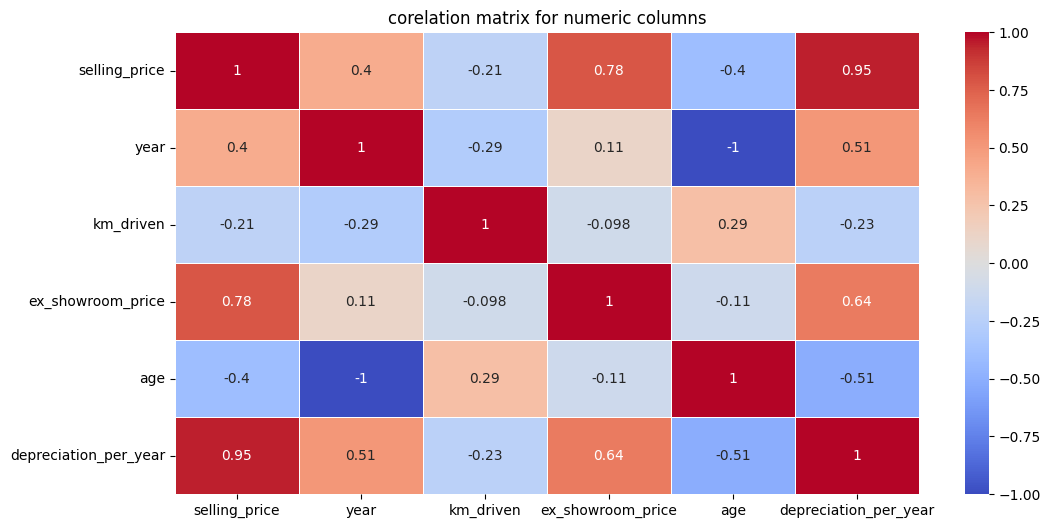

In [68]:
# Develop a correlation matrix for numeric columns and visualize it using a heatmap.
num_df = df.select_dtypes(include=['int','float'])
corr_mtrx=num_df.corr()
plt.figure(figsize = (12,6))
sns.heatmap(corr_mtrx,annot=True,cmap='coolwarm',linewidth=0.5)
plt.title("corelation matrix for numeric columns")
plt.show()